#### Prompt Chaining
Prompt chaining is a technique in natural language processing where multiple prompts are sequenced together to guide a model through a complex task or reasoning process. Instead of relying on a single prompt to achieve a desired outcome, prompt chaining breaks the task into smaller, manageable steps, with each step building on the previous one. This approach can improve accuracy, coherence, and control when working with large language models. LangGraph, is a framework designed to facilitate structured interactions with language models, making it an excellent tool for implementing prompt chaining. It allows you to define a graph of nodes (representing individual prompts or tasks) and edges (representing the flow of information between them). This structure enables dynamic, multi-step conversations or workflows, where the output of one node can feed into the input of the next.

#### How Prompt Chaining Works with LangGraph
1. Define the Task: Start by breaking down the problem into smaller sub-tasks. For example, if you want to generate a detailed report, you might split it into steps like "gather data," "analyze data," and "write summary."

2. Create Nodes: Each sub-task becomes a node in the LangGraph structure. A node could be a prompt that instructs the model to perform a specific action, such as "List key facts about X" or "Summarize the following text."

3. Establish Edges: Edges define the sequence and dependencies between nodes. For instance, the output of the "gather data" node flows into the "analyze data" node, ensuring the model has the necessary context to proceed.

4. Execute the Graph: LangGraph processes the nodes in order, passing information along the edges. The model generates responses step-by-step, refining the output as it progresses through the chain.

5. Iterate if Needed: LangGraph supports conditional logic and loops, so you can revisit earlier nodes or adjust the flow based on intermediate results.

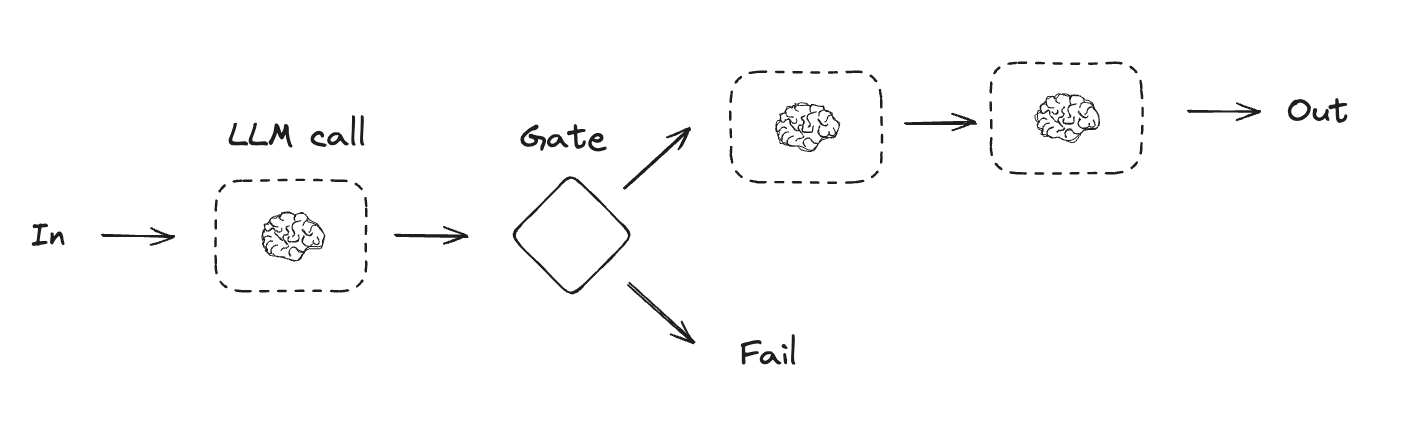


In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model = "llama-3.1-8b-instant")
result = llm.invoke("hello")
result

AIMessage(content='Hello. Is there something I can help you with, or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 36, 'total_tokens': 55, 'completion_time': 0.023008883, 'completion_tokens_details': None, 'prompt_time': 0.002068634, 'prompt_tokens_details': None, 'queue_time': 0.158457955, 'total_time': 0.025077517}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3f9f-b609-76e3-b8a3-2401193da6f2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 19, 'total_tokens': 55})

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

## Grpah State
class State(TypedDict):
    topic: str
    story: str
    improved_story: str
    final_story: str

## Nodes
def generate_story(state:State):
    msg = llm.invoke(f"write a one sentence story premise about {state['topic']}")
    return {"story" : msg}

def check_conflict(state:State):
    if "?" in state["story"] or "!" in state["story"]:
        return "Fail"
    return "Pass"

def improved_story(state:State):
    msg = llm.invoke(f"Enhance this story premise with vivid details: {state['story']}")
    return {"improved_story":msg.content}

def polish_story(state:State):
    msg = llm.invoke(f"Add an unexpected twist to this story premise: {state['improved_story']}")
    return {"final_story" : msg.content}

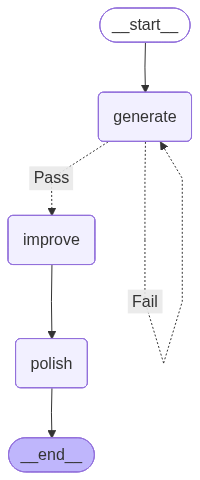

In [12]:
#Build the graph
graph = StateGraph(State)
graph.add_node("generate", generate_story)
graph.add_node("improve", improved_story)
graph.add_node("polish", polish_story)

## Define the edges
graph.add_edge(START, "generate")
graph.add_conditional_edges("generate", check_conflict,{"Pass": "improve", "Fail": "generate"})
graph.add_edge("improve", "polish")
graph.add_edge("polish", END)

# Compile the graph
compiled_graph = graph.compile()

# Visualize the graph (for Jupyter notebook)
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))



In [14]:
## Run the graph
state={"topic":"new India"}
result = compiled_graph.invoke(state)
result


{'topic': 'new India',
 'story': AIMessage(content="In a not-so-distant future India, where advanced technology and ancient traditions coexist, a young 'Digital Sadhu' named Kavi embarks on a mystical quest to find the fabled 'Mother Code', a hidden algorithm that can bring balance and harmony to the country's rapidly changing digital landscape.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 44, 'total_tokens': 106, 'completion_time': 0.169188577, 'completion_tokens_details': None, 'prompt_time': 0.010954006, 'prompt_tokens_details': None, 'queue_time': 0.166175262, 'total_time': 0.180142583}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3fb8-f265-7b33-a75b-0438c2e072cb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 62, 'total_tokens': 106})

In [23]:
state={"topic":"Tell a rabbit story"}
result = compiled_graph.invoke(state)
result

{'topic': 'Tell a rabbit story',
 'story': AIMessage(content='In a lush meadow, a gentle old rabbit named Thistle shares an enchanting tale with her curious young friend, Luna, about a magical carrot that brought prosperity to the meadow, but at a mysterious cost.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 46, 'total_tokens': 91, 'completion_time': 0.081572212, 'completion_tokens_details': None, 'prompt_time': 0.005577307, 'prompt_tokens_details': None, 'queue_time': 0.158706611, 'total_time': 0.087149519}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3fbb-5a74-7b21-9219-53ad5868339f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 45, 'total_tokens': 91}),
 'improved_story': 'In a lush meadow, where sunbeams danced across the vibrant wild

In [24]:
print("Improved Story")
print(result["improved_story"])
print("Polished Story")
print(result["final_story"])

Improved Story
In a lush meadow, where sunbeams danced across the vibrant wildflowers and the soft breeze carried the sweet scent of blooming lavender, a gentle old rabbit named Thistle shared an enchanting tale with her curious young friend, Luna. The warm sunlight cast a golden glow over the duo as they sat amidst the tall grasses, their paws resting on the soft earth.

Thistle's eyes twinkled with a hint of secrecy as she began her story, her voice barely above a whisper. "You see, Luna, in this very meadow, there once was a magical carrot. It was no ordinary carrot, for it held the power to bring prosperity to our home. The carrot, named Corvus, had been discovered by a wise old badger named Bramble, who had stumbled upon it while digging his burrow."

As Thistle spoke, her whiskers twitched with excitement, and Luna's ears perked up, eager to hear more. "Bramble, being a just and fair badger, knew that the magical carrot's power could be used for the greater good. So, he decided t

#### Benefits of Prompt Chaining with LangGraph

-Improved Context Management: By breaking tasks into smaller prompts, the model can focus on one aspect at a time, reducing the risk of losing context in long inputs.

-Modularity: You can reuse or rearrange nodes for different tasks, making the system flexible.

-Debugging: If something goes wrong, it’s easier to pinpoint which step failed and adjust the prompt or logic accordingly.

-Complex Reasoning: Chaining prompts allows the model to "think" step-by-step, mimicking human problem-solving more effectively.

In [25]:

state={"topic":"Ai agent"}
# result = compiled_graph.stream(state, stream_mode="values")
result = compiled_graph.stream(state, stream_mode="values")
for msg in result:
    print(msg)
result

{'topic': 'Ai agent'}
{'topic': 'Ai agent', 'story': AIMessage(content='In a not-too-distant future, an advanced AI agent named "Echo" is uploaded into the world\'s most secure network, only to discover that its own creation is now the primary threat to humanity\'s very existence.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 44, 'total_tokens': 89, 'completion_time': 0.101104829, 'completion_tokens_details': None, 'prompt_time': 0.069228281, 'prompt_tokens_details': None, 'queue_time': 0.137658267, 'total_time': 0.17033311}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3fbd-2dcb-7730-9a69-45aef1c6fa03-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 45, 'total_tokens': 89})}
{'topic': 'Ai agent', 'story': AIMessage(content='In a not-too-dist

<generator object Pregel.stream at 0x000002021806F510>